In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.ensemble import AdaBoostClassifier, BaggingClassifier, GradientBoostingClassifier, RandomForestClassifier, StackingClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve, f1_score
from sklearn.model_selection import KFold, StratifiedKFold, cross_val_score, learning_curve, train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import SelectFromModel
from sklearn.model_selection import GridSearchCV
import os
import mlflow
from datetime import datetime

In [ ]:
MLRUNS_DIR = os.path.abspath(f"./my_mlflow_runs_{datetime.now().strftime('%Y%m%d_%H%M%S')}")
os.makedirs(MLRUNS_DIR, exist_ok=True)

mlflow.set_tracking_uri(f"file:{MLRUNS_DIR}")
mlflow.set_registry_uri(f"file:{MLRUNS_DIR}")

EXPERIMENT_NAME = "ML2_CustomerValue_Project"
mlflow.set_experiment(EXPERIMENT_NAME)

print("NEW Tracking URI:", mlflow.get_tracking_uri())
print("NEW Registry URI:", mlflow.get_registry_uri())
print("Experiment:", EXPERIMENT_NAME)


d:\Downloads\Anaconda\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:177: FutureWarning: The filesystem tracking backend (e.g., './mlruns') will be deprecated in February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://github.com/mlflow/mlflow/issues/18534 for more details and migration guidance.
  return FileStore(store_uri, store_uri)
2025/12/20 16:25:58 INFO mlflow.tracking.fluent: Experiment with name 'ML2_CustomerValue_Project' does not exist. Creating a new experiment.


NEW Tracking URI: file:d:\University\3rd Year\Machine Learning\Project\my_mlflow_runs_20251220_162558
NEW Registry URI: file:d:\University\3rd Year\Machine Learning\Project\my_mlflow_runs_20251220_162558
Experiment: ML2_CustomerValue_Project


In [ ]:
SAVED_MODELS_DIR = "saved_models"
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)

def log_and_export_model(model, run_name, X_test, y_test, model_export_name, params=None, tags=None):
    params = params or {}
    tags = tags or {}

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    export_path = os.path.join(SAVED_MODELS_DIR, f"{model_export_name}_{stamp}")

    with mlflow.start_run(run_name=run_name) as run:
        for k,v in params.items():
            mlflow.log_param(k, v)
        for k,v in tags.items():
            mlflow.set_tag(k, v)

        y_pred = model.predict(X_test)
        mlflow.log_metric("test_accuracy", accuracy_score(y_test, y_pred))
        mlflow.log_metric("test_f1", f1_score(y_test, y_pred, average='weighted'))

        mlflow.sklearn.log_model(model, artifact_path="model")
        mlflow.sklearn.save_model(model, export_path)

        print("Run logged:", run.info.run_id)
        print("Model exported to:", export_path)

    return export_path


In [4]:
df = pd.read_csv("train.csv")
df.head()

,Employee ID,Age,Gender,Years at Company,Job Role,Monthly Income,Work-Life Balance,Job Satisfaction,Performance Rating,Number of Promotions,...,Number of Dependents,Job Level,Company Size,Company Tenure,Remote Work,Leadership Opportunities,Innovation Opportunities,Company Reputation,Employee Recognition,Attrition
0,8410,31,Male,19,Education,5390,Excellent,Medium,Average,2,...,0,Mid,Medium,89,No,No,No,Excellent,Medium,Stayed
1,64756,59,Female,4,Media,5534,Poor,High,Low,3,...,3,Mid,Medium,21,No,No,No,Fair,Low,Stayed
2,30257,24,Female,10,Healthcare,8159,Good,High,Low,0,...,3,Mid,Medium,74,No,No,No,Poor,Low,Stayed
3,65791,36,Female,7,Education,3989,Good,High,High,1,...,2,Mid,Small,50,Yes,No,No,Good,Medium,Stayed
4,65026,56,Male,41,Education,4821,Fair,Very High,Average,0,...,0,Senior,Medium,68,No,No,No,Fair,Medium,Stayed


In [ ]:
np.random.seed(42)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist() #Selected 3 random numeric columns to add nulls
if 'Attrition' in numeric_cols: numeric_cols.remove('Attrition') #but not in targettt
cols_to_null = np.random.choice(numeric_cols, 3, replace=False)
print(f"Columns selected for artificial nulls: {cols_to_null}")

#Inject NaNs into 2% of the data in these columns
for col in cols_to_null:
    n_nulls = int(len(df) * 0.02)
    indices = np.random.choice(df.index, n_nulls, replace=False)
    df.loc[indices, col] = np.nan

print("Artificial nulls injected.")
print(df[cols_to_null].isnull().sum())


Columns selected for artificial nulls: ['Age' 'Distance from Home' 'Employee ID']
Artificial nulls injected.
Age                   1191
Distance from Home    1191
Employee ID           1191
dtype: int64


Correlation with Attrition:
Attrition_Encoded       1.000000
Number of Promotions    0.080591
Number of Dependents    0.078337
Years at Company        0.064909
Age                     0.046978
Company Tenure          0.030285
Monthly Income          0.011377
Employee ID            -0.002620
Distance from Home     -0.095254
Name: Attrition_Encoded, dtype: float64


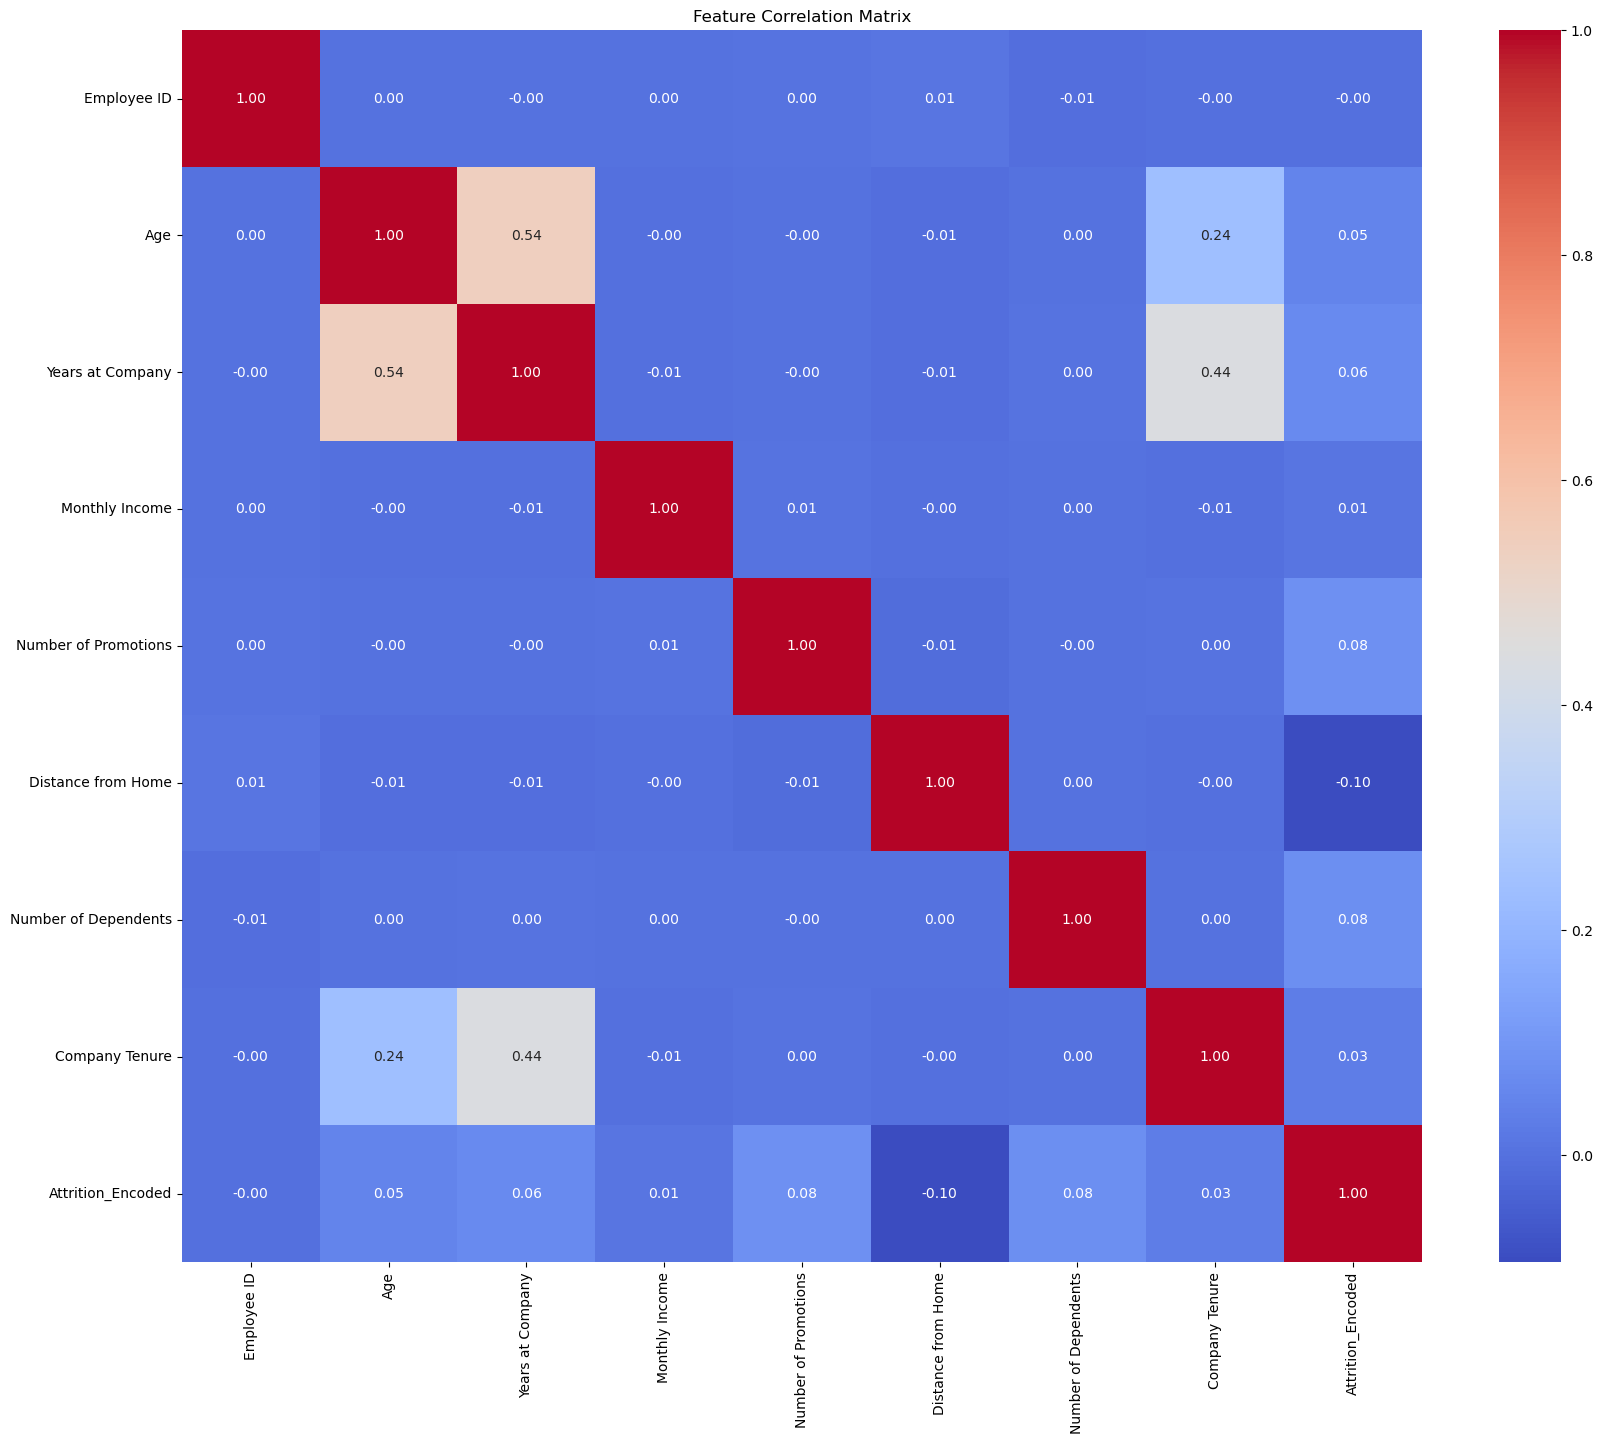

In [ ]:
# Encode Attrition(target) for correlation analysis
le = LabelEncoder()
if df['Attrition'].dtype == 'object':
    df['Attrition_Encoded'] = le.fit_transform(df['Attrition'])
else:
    df['Attrition_Encoded'] = df['Attrition']

numeric_df = df.select_dtypes(include=[np.number])
correlations = numeric_df.corr()['Attrition_Encoded'].sort_values(ascending=False)

print("Correlation with Attrition:")
print(correlations)
#visualize correlation matrix
plt.figure(figsize=(20, 16))
sns.heatmap(numeric_df.corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Feature Correlation Matrix')
plt.show()


In [ ]:
SAVED_MODELS_DIR = "saved_models"
os.makedirs(SAVED_MODELS_DIR, exist_ok=True)

def log_and_export_model(model, run_name, X_test, y_test, model_export_name, params=None, tags=None):
    params = params or {}
    tags = tags or {}

    stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    export_path = os.path.join(SAVED_MODELS_DIR, f"{model_export_name}_{stamp}")

    with mlflow.start_run(run_name=run_name) as run:
        for k,v in params.items():
            mlflow.log_param(k, v)
        for k,v in tags.items():
            mlflow.set_tag(k, v)

        y_pred = model.predict(X_test)
        mlflow.log_metric("test_accuracy", accuracy_score(y_test, y_pred))
        mlflow.log_metric("test_f1", f1_score(y_test, y_pred, average='weighted'))

        mlflow.sklearn.log_model(model, artifact_path="model")
        mlflow.sklearn.save_model(model, export_path)

        print("Run logged:", run.info.run_id)
        print("Model exported to:", export_path)

    return export_path


# Dataset Description

The **Attrition** dataset is used for this analysis. The goal is to predict employee attrition (binary classification).

### Dataset Overview
*   **Target Variable**: `Attrition` (Yes/No mapped to 1/0)
*   **Features**: Various numerical and categorical features related to employee demographics, job role, and satisfaction.

### Data Preprocessing Logic
*   **Missing Values**:
    *   Artificial nulls were injected (2%) into random numeric columns for demonstration.
    *   **Imputation**: KNNImputer is used for numeric columns, and Mode Imputation for categorical columns.
*   **Outlier Handling**:
    *   Outliers in numeric columns like `MonthlyIncome` and `TotalWorkingYears` are capped using the IQR method.
*   **Feature Engineering**:
    *   Categorical variables are encoded using Label Encoding/One-Hot Encoding within the modeling pipelines.


### Correlation Analysis\n
Checking correlation between features and the target variable 'Attrition'.\n
First, we need to encode 'Attrition' to numeric.

In [8]:
X = df.drop(['Attrition', 'Attrition_Encoded'], axis=1, errors='ignore')
Y = df['Attrition_Encoded']

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y,
    test_size=0.3,
    random_state=42,
    stratify=Y
)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("Y_train:", Y_train.shape)
print("Y_test :", Y_test.shape)


X_train: (41718, 23)
X_test : (17880, 23)
Y_train: (41718,)
Y_test : (17880,)


### Exploratory Data Analysis (EDA)
Visualizing key relationships between features and employee attrition.


In [9]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()

mean_before = X_train[num_cols].mean()
var_before = X_train[num_cols].var()

print("Mean (before cleaning):")
print(mean_before)

print("\nVariance (before cleaning):")
print(var_before)


Mean (before cleaning):
Employee ID             37267.890555
Age                        38.557917
Years at Company           15.720504
Monthly Income           7310.934105
Number of Promotions        0.832638
Distance from Home         49.981624
Number of Dependents        1.650966
Company Tenure             55.779256
dtype: float64

Variance (before cleaning):
Employee ID             4.639101e+08
Age                     1.456137e+02
Years at Company        1.263592e+02
Monthly Income          4.622631e+06
Number of Promotions    9.900875e-01
Distance from Home      8.095402e+02
Number of Dependents    2.427133e+00
Company Tenure          6.462382e+02
dtype: float64


In [10]:
num_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = [c for c in X_train.columns if c not in num_cols]

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)


Numeric columns: ['Employee ID', 'Age', 'Years at Company', 'Monthly Income', 'Number of Promotions', 'Distance from Home', 'Number of Dependents', 'Company Tenure']
Categorical columns: ['Gender', 'Job Role', 'Work-Life Balance', 'Job Satisfaction', 'Performance Rating', 'Overtime', 'Education Level', 'Marital Status', 'Job Level', 'Company Size', 'Remote Work', 'Leadership Opportunities', 'Innovation Opportunities', 'Company Reputation', 'Employee Recognition']


In [11]:
X_train.isnull().sum()

Employee ID                 830
Age                         823
Gender                        0
Years at Company              0
Job Role                      0
Monthly Income                0
Work-Life Balance             0
Job Satisfaction              0
Performance Rating            0
Number of Promotions          0
Overtime                      0
Distance from Home          850
Education Level               0
Marital Status                0
Number of Dependents          0
Job Level                     0
Company Size                  0
Company Tenure                0
Remote Work                   0
Leadership Opportunities      0
Innovation Opportunities      0
Company Reputation            0
Employee Recognition          0
dtype: int64

In [12]:
# Handle missing values using proper imputation techniques

# Separate numeric and categorical columns
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
categorical_cols = X_train.select_dtypes(exclude=[np.number]).columns

# 1. Numeric: Use KNN Imputer (as requested)
# Using n_neighbors=5 as a standard start.
knn_imputer = KNNImputer(n_neighbors=5)

# Apply to X_train and X_test (fit on train, transform test)
X_train[numeric_cols] = knn_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = knn_imputer.transform(X_test[numeric_cols])

# 2. Categorical: Use Mode (Most Frequent) Imputation
cat_imputer = SimpleImputer(strategy='most_frequent')

X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

print("Missing values handled using KNN (numeric) and Mode (categorical).")


Missing values handled using KNN (numeric) and Mode (categorical).


In [13]:
X_train.isnull().sum()

Employee ID                 0
Age                         0
Gender                      0
Years at Company            0
Job Role                    0
Monthly Income              0
Work-Life Balance           0
Job Satisfaction            0
Performance Rating          0
Number of Promotions        0
Overtime                    0
Distance from Home          0
Education Level             0
Marital Status              0
Number of Dependents        0
Job Level                   0
Company Size                0
Company Tenure              0
Remote Work                 0
Leadership Opportunities    0
Innovation Opportunities    0
Company Reputation          0
Employee Recognition        0
dtype: int64

In [14]:
def outlier(i):
    Q1=X_train[i].quantile(0.25)
    Q3=X_train[i].quantile(0.75)
    IQR=Q3-Q1
    lowerbound= Q1-1.5*IQR
    upperbound= Q3+1.5*IQR
    return lowerbound,upperbound

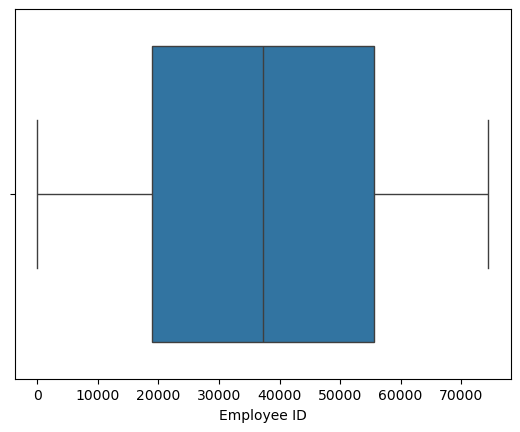

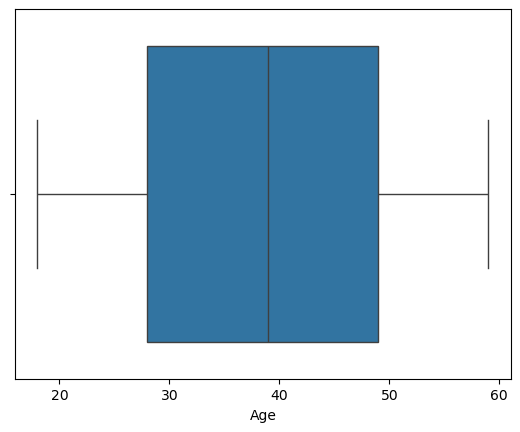

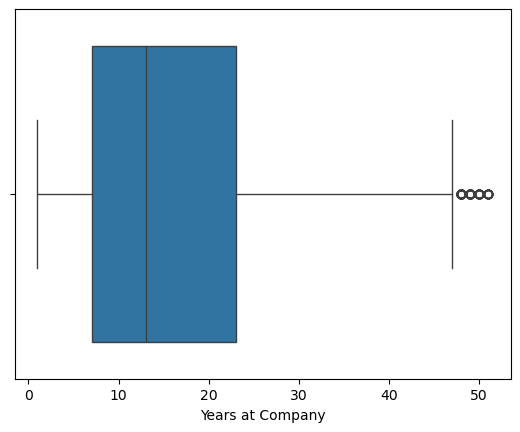

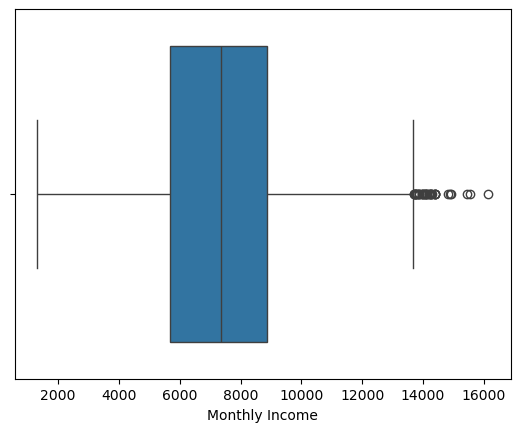

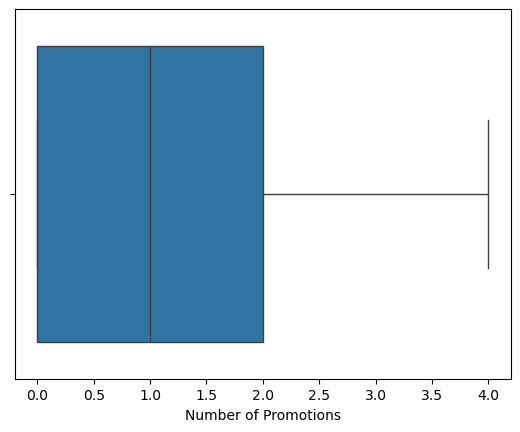

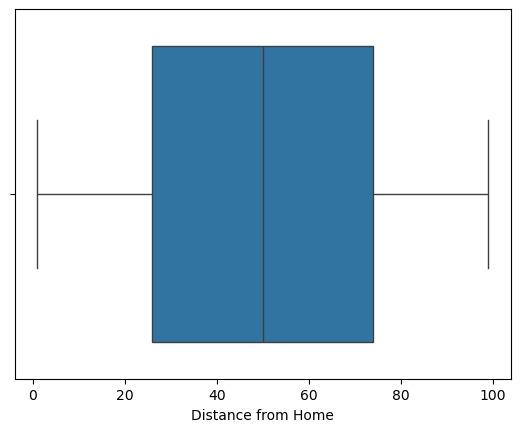

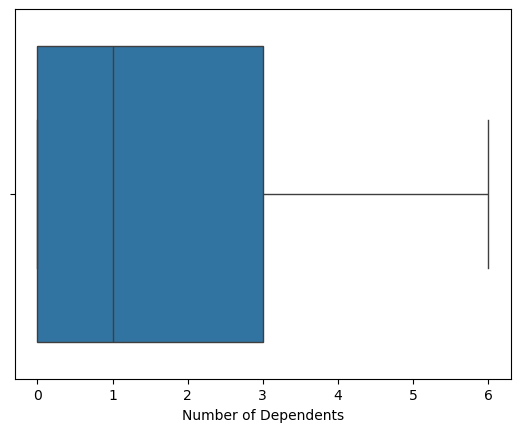

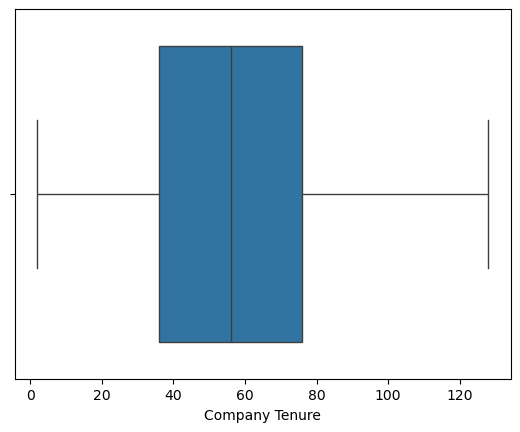

In [15]:
for i in X_train.select_dtypes(include="number").columns:
    sns.boxplot(data=X_train,x=i)
    plt.show()

In [16]:
for i in X_train.select_dtypes(include="number").columns:
    lowerbound,upperbound=outlier(i)
    X_train[i]=np.where(X_train[i]<lowerbound,lowerbound,X_train[i])
    X_train[i]=np.where(X_train[i]>upperbound, upperbound,X_train[i])

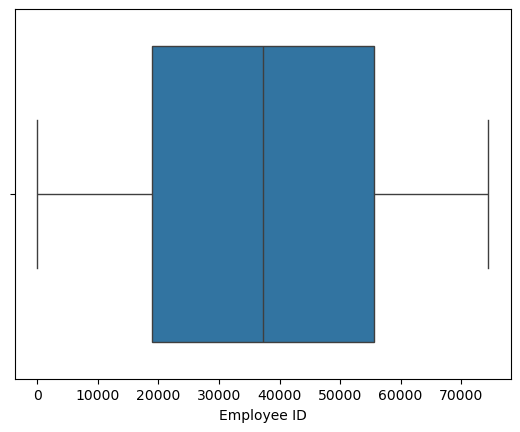

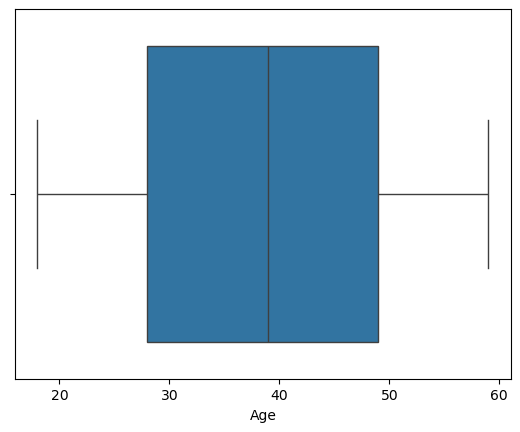

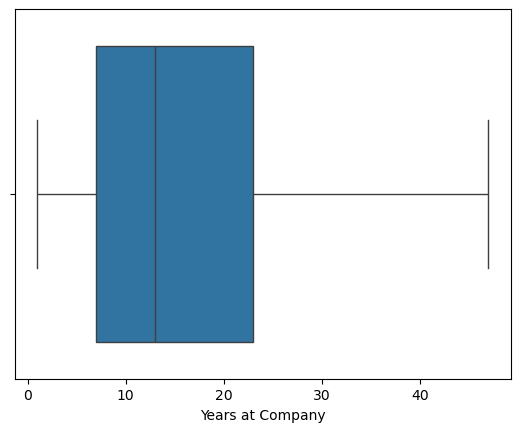

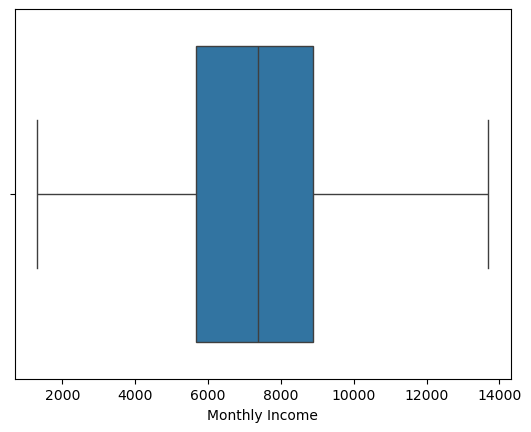

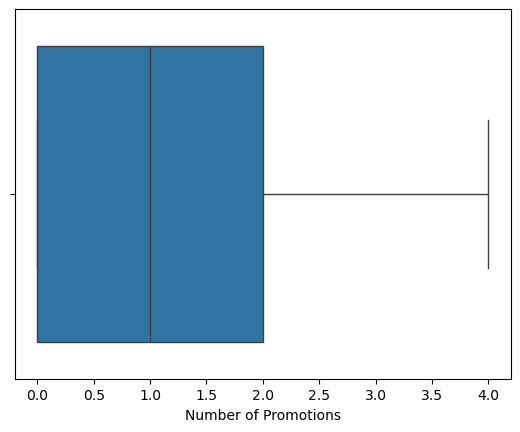

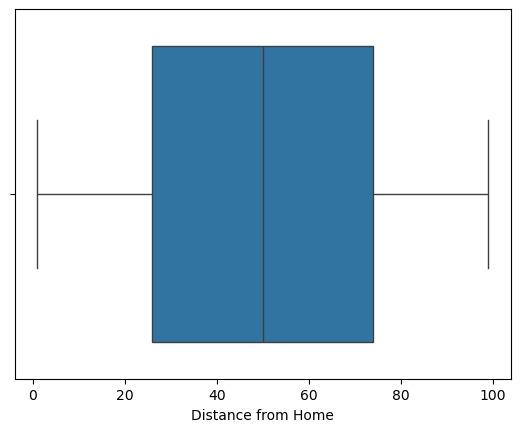

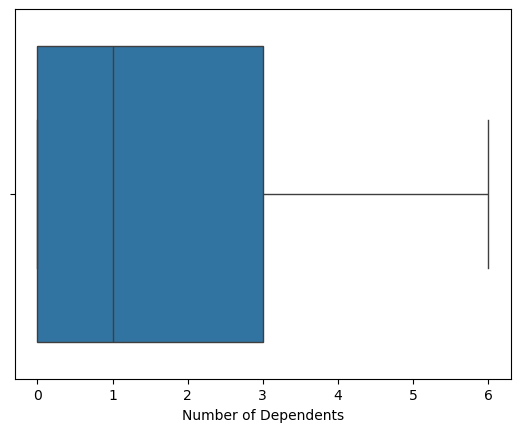

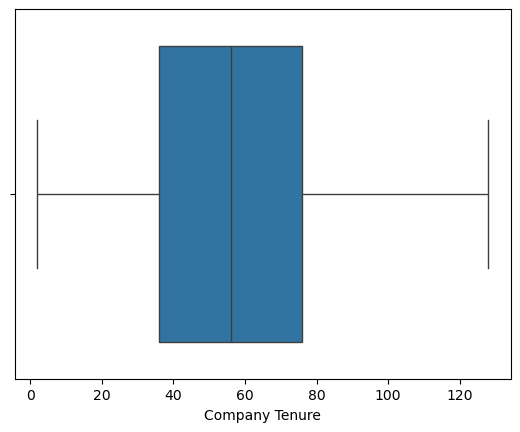

In [17]:
for i in X_train.select_dtypes(include="number").columns:
    sns.boxplot(data=X_train,x=i)
    plt.show()

In [18]:
X_train_numeric = X_train.select_dtypes(include=['number'])

print("AFTER CLEANING — TRAIN")
print("Mean (X_train):")
print(X_train_numeric.mean())

print("\nVariance (X_train):")
print(X_train_numeric.var())

AFTER CLEANING — TRAIN
Mean (X_train):
Employee ID             37264.177755
Age                        38.552447
Years at Company           15.711012
Monthly Income           7310.448044
Number of Promotions        0.832638
Distance from Home         49.933017
Number of Dependents        1.650966
Company Tenure             55.779256
dtype: float64

Variance (X_train):
Employee ID             4.565058e+08
Age                     1.433653e+02
Years at Company        1.257412e+02
Monthly Income          4.615894e+06
Number of Promotions    9.900875e-01
Distance from Home      7.962222e+02
Number of Dependents    2.427133e+00
Company Tenure          6.462382e+02
dtype: float64


# Exploratory Data Analysis (EDA) on Training Data
Visualizations based on the split training set to prevent data leakage.

In [19]:
# Re-creating DataFrame for Visualization from Training Split
visualization_df = X_train.copy()
visualization_df['Attrition'] = Y_train
sns.set_theme(context="notebook", style="whitegrid", font_scale=1.1)


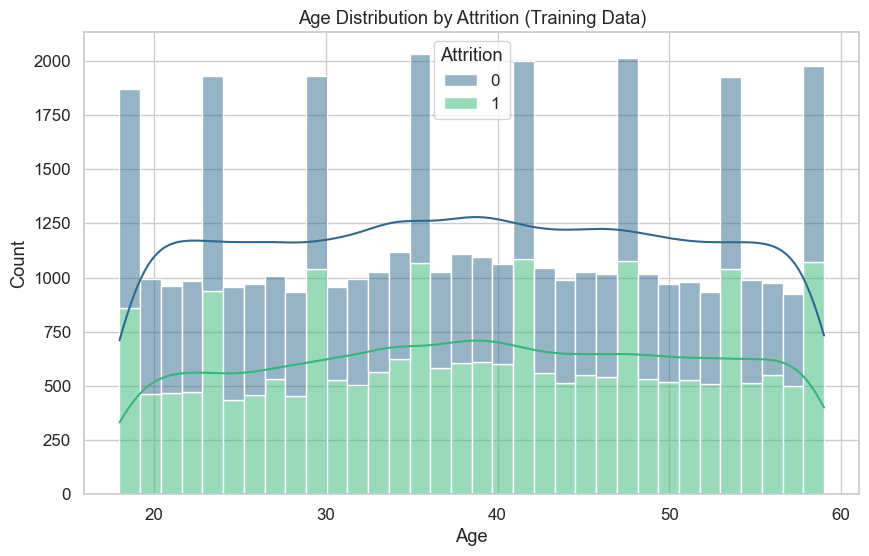

In [20]:
# 1. Age Distribution by Attrition (Training Set)
plt.figure(figsize=(10, 6))
sns.histplot(data=visualization_df, x='Age', hue='Attrition', multiple='stack', kde=True, palette='viridis')
plt.title('Age Distribution by Attrition (Training Data)')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

C:\Users\HP\AppData\Local\Temp\ipykernel_10168\3539889467.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=visualization_df, x='Attrition', y='Monthly Income', palette='viridis')


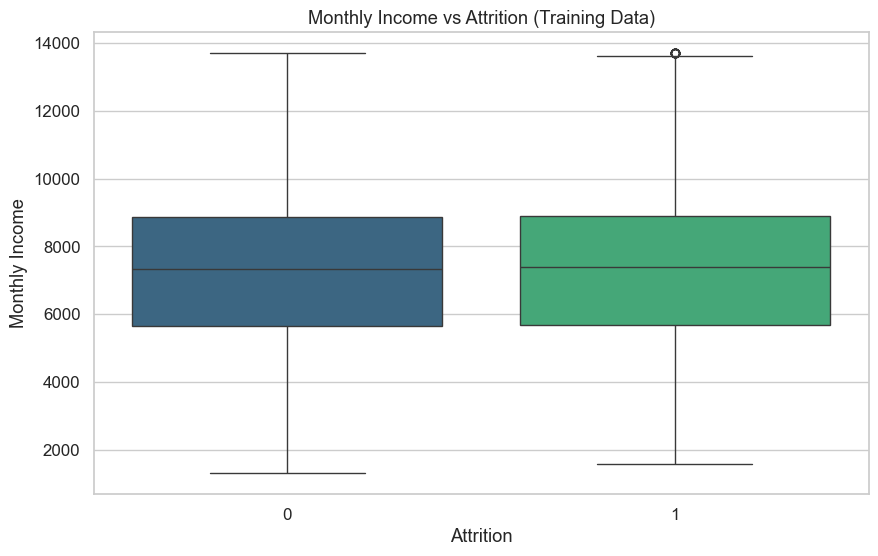

In [21]:
# 2. Monthly Income Distribution by Attrition (Training Set)
plt.figure(figsize=(10, 6))
sns.boxplot(data=visualization_df, x='Attrition', y='Monthly Income', palette='viridis')
plt.title('Monthly Income vs Attrition (Training Data)')
plt.xlabel('Attrition')
plt.ylabel('Monthly Income')
plt.show()

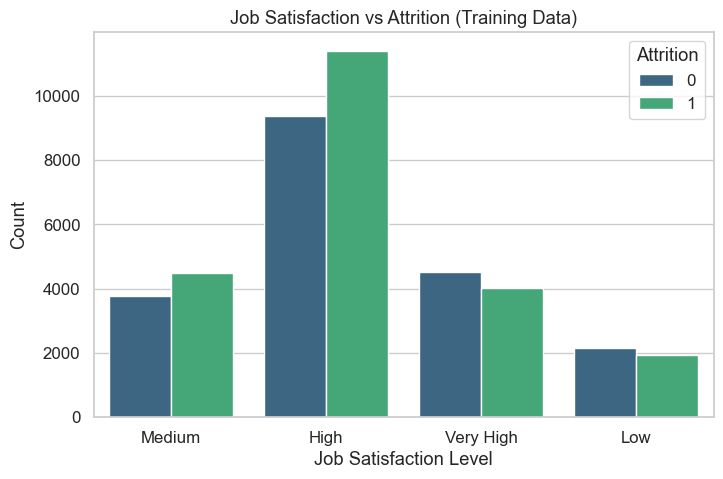

In [22]:
# 3. Job Satisfaction Count by Attrition (Training Set)
plt.figure(figsize=(8, 5))
sns.countplot(data=visualization_df, x='Job Satisfaction', hue='Attrition', palette='viridis')
plt.title('Job Satisfaction vs Attrition (Training Data)')
plt.xlabel('Job Satisfaction Level')
plt.ylabel('Count')
plt.show()

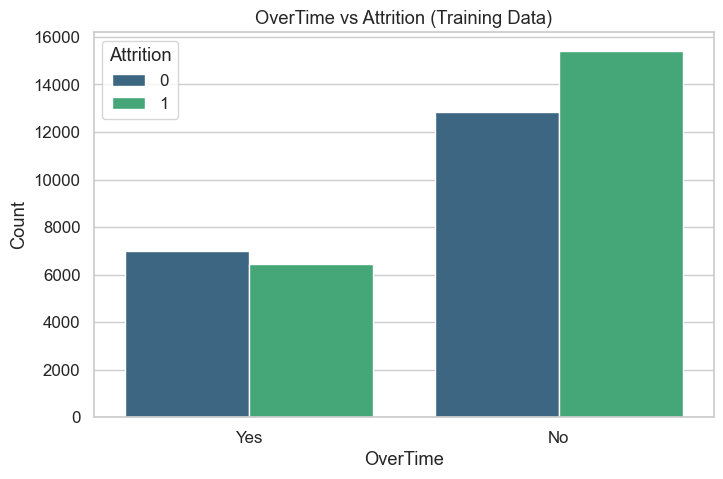

In [23]:
# 4. OverTime Effect on Attrition (Training Set) - (Fixed Column Name)
plt.figure(figsize=(8, 5))
# Note: Column name is 'Overtime' (lowercase t) in the dataset
sns.countplot(data=visualization_df, x='Overtime', hue='Attrition', palette='viridis')
plt.title('OverTime vs Attrition (Training Data)')
plt.xlabel('OverTime')
plt.ylabel('Count')
plt.show()

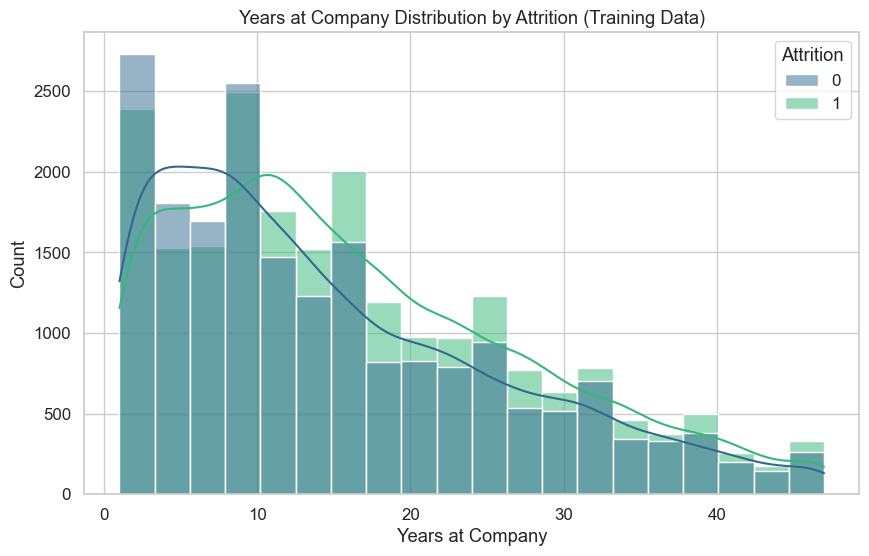

In [24]:
# 5. Years at Company Distribution by Attrition (Training Set) - (Switched to Histplot)
plt.figure(figsize=(10, 6))
# Using histplot with kde=True is often more robust for integer data than pure kdeplot
sns.histplot(data=visualization_df, x='Years at Company', hue='Attrition', kde=True, palette='viridis', alpha=0.5, bins=20)
plt.title('Years at Company Distribution by Attrition (Training Data)')
plt.xlabel('Years at Company')
plt.show()

### Feature Selection
Selecting the top 10 most predictive features using ANOVA F-value (f_classif). Placed after Split to ensure X_train exists.

In [25]:
# Helper Function to Visualize Top 10 Features from Pipeline
def visualize_pipeline_features(pipeline, feature_names, title, k=10):
    if 'fs' in pipeline.named_steps:
        fs = pipeline.named_steps['fs']
        scores = fs.scores_
        # Get indices of top k scores
        top_indices = np.argsort(scores)[::-1][:k]
        top_features = [feature_names[i] for i in top_indices]
        top_scores = scores[top_indices]
        
        plt.figure(figsize=(10, 6))
        sns.barplot(x=top_scores, y=top_features, palette='viridis')
        plt.title(f'Top {k} Features - {title}')
        plt.xlabel('ANOVA F-value')
        plt.ylabel('Feature')
        plt.show()
    else:
        print(f'No Feature Selection step found in {title} pipeline.')


In [26]:
# Label Encoding for Categorical Variables

# Identifies categorical columns in the training data
cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()

encoders = {}
for col in cat_cols:
    le = LabelEncoder()
    # Fit on combined data to ensure all categories are covered
    combined = pd.concat([X_train[col], X_test[col]], axis=0).astype(str)
    le.fit(combined)
    X_train[col] = le.transform(X_train[col].astype(str))
    X_test[col]  = le.transform(X_test[col].astype(str))
    encoders[col] = le

print("Label Encoding complete for all categorical columns in X_train and X_test.")

Label Encoding complete for all categorical columns in X_train and X_test.


# Task 2: Model Building - Individual Models
We will implement and train three individual models:
1.  **Logistic Regression**
2.  **Random Forest Classifier**
3.  **Support Vector Machine (SVM)**

We use `scikit-learn` Pipelines to handle scaling and model training efficiently.


In [27]:
def plot_gridsearch_results(grid, x_param, title, hue_param=None):
    """
    grid: fitted GridSearchCV
    x_param: column name in cv_results_ like 'param_model__C'
    hue_param: optional second param column like 'param_model__gamma'
    """
    results = pd.DataFrame(grid.cv_results_)

    plt.figure(figsize=(8, 5))

    if hue_param is None:
        # Simple line plot (average score per x value)
        grouped = results.groupby(x_param)["mean_test_score"].mean().reset_index()
        plt.plot(grouped[x_param].astype(str), grouped["mean_test_score"], marker="o")
        plt.xlabel(x_param)
        plt.ylabel("Mean CV Score")
        plt.title(title)
        plt.grid(True)
        plt.tight_layout()
        plt.show()
    else:
        # Plot multiple lines (one line per hue value)
        for hue_val in sorted(results[hue_param].astype(str).unique()):
            sub = results[results[hue_param].astype(str) == hue_val]
            grouped = sub.groupby(x_param)["mean_test_score"].mean().reset_index()
            plt.plot(grouped[x_param].astype(str), grouped["mean_test_score"], marker="o", label=f"{hue_param}={hue_val}")

        plt.xlabel(x_param)
        plt.ylabel("Mean CV Score")
        plt.title(title)
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()


In [28]:
def plot_learning_curve_model(estimator, title, X=None, y=None):
    if X is None: X = X_train
    if y is None: y = Y_train
    train_sizes, train_scores, test_scores = learning_curve(
        estimator, X, y, cv=3, n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5), scoring='accuracy'
    )
    train_scores_mean = np.mean(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)

    plt.figure()
    plt.title(title)
    plt.xlabel('Training examples')
    plt.ylabel('Accuracy')
    plt.grid()
    plt.plot(train_sizes, train_scores_mean, 'o-', color='r', label='Training score')
    plt.plot(train_sizes, test_scores_mean, 'o-', color='g', label='Validation score')
    plt.legend(loc='best')
    plt.show()


In [29]:
def show_l1_selected_features(pipeline, feature_names, title):
    fs_step = pipeline.named_steps['fs']
    selected_mask = fs_step.get_support()
    selected_features = np.array(feature_names)[selected_mask]
    print(f"\n{title} - Selected features count: {len(selected_features)}")
    print("Selected features:\n", list(selected_features))

Best LR Params: {'fs__estimator__C': 0.01, 'model__C': 10}
Best LR CV AUC: 0.7886331131621495


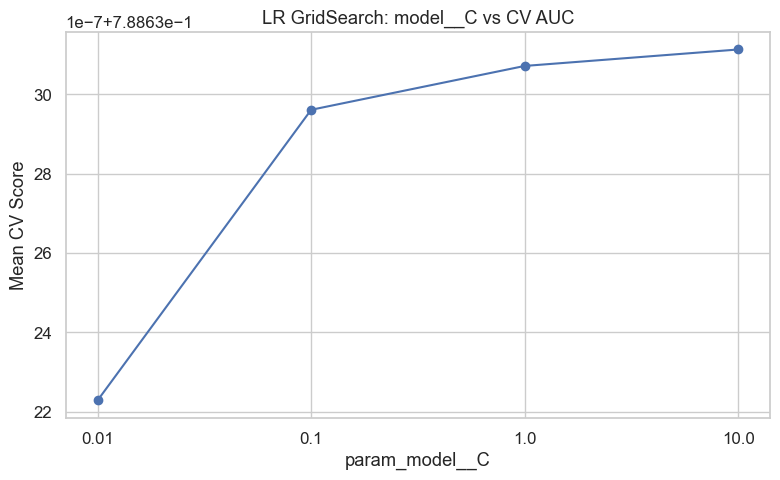

In [30]:
# ===== Logistic Regression with L1 Feature Selection =====
l1_selector = SelectFromModel(
    estimator=LogisticRegression(
        penalty="l1",
        solver="liblinear",
        C=1.0,
        max_iter=2000,
        random_state=42
    ),
    threshold="median"
)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('fs', l1_selector),
    ('model', LogisticRegression(
        penalty="l2",
        solver="liblinear",
        C=1.0,
        max_iter=2000,
        random_state=42
    ))
])

param_grid_lr = {
    "fs__estimator__C": [0.01, 0.1, 1, 10],
    "model__C": [0.01, 0.1, 1, 10]
}

grid_lr = GridSearchCV(
    estimator=lr_pipeline,
    param_grid=param_grid_lr,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)

grid_lr.fit(X_train, Y_train)
best_lr = grid_lr.best_estimator_

print("Evaluating Logistic Regression ")
# 1. Training
y_train_pred_lr  = best_lr.predict(X_train)
y_train_proba_lr = best_lr.predict_proba(X_train)[:, 1]
y_test_pred_lr   = best_lr.predict(X_test)
y_test_proba_lr  = best_lr.predict_proba(X_test)[:, 1]

# Metrics & Classification Report
print("Classification Report:")
print(classification_report(Y_test, y_test_pred_lr))

# Confusion Matrix
cm = confusion_matrix(Y_test, y_test_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: Logistic Regression")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
auc_score = roc_auc_score(Y_test, y_test_proba_lr)
fpr, tpr, _ = roc_curve(Y_test, y_test_proba_lr)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title(f"ROC Curve: Logistic Regression")
plt.legend()
plt.show()


--- Evaluating Logistic Regression ---
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.69      0.69      8502
           1       0.72      0.73      0.72      9378

    accuracy                           0.71     17880
   macro avg       0.71      0.71      0.71     17880
weighted avg       0.71      0.71      0.71     17880



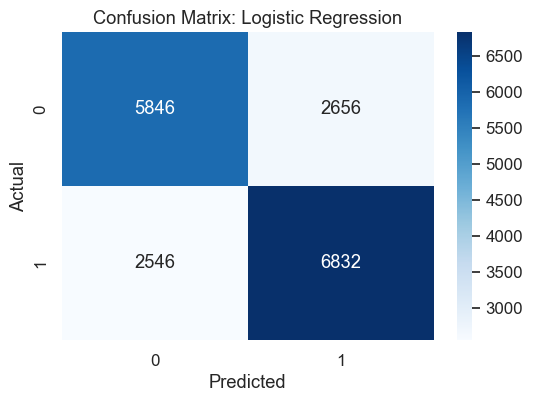

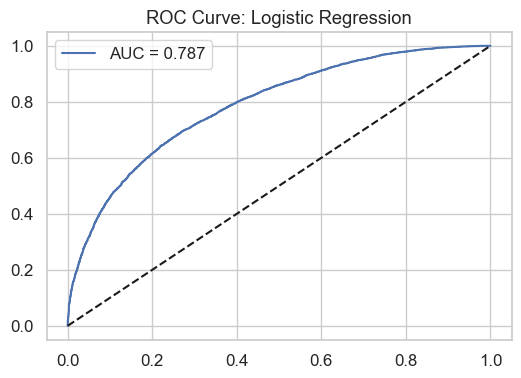

In [31]:
print("--- Evaluating Logistic Regression ---")
# 1. Predictions
y_pred = best_lr.predict(X_test)
y_prob = None
if hasattr(best_lr, "predict_proba"):
    try: y_prob = best_lr.predict_proba(X_test)[:, 1]
    except: pass
elif hasattr(best_lr, "decision_function"):
    try: 
        y_prob = best_lr.decision_function(X_test)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    except: pass

# 2. Metrics & Report
print("Classification Report:")
print(classification_report(Y_test, y_pred))

# 3. Validation Matrices
# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: Logistic Regression")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
if y_prob is not None:
    auc_score = roc_auc_score(Y_test, y_prob)
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve: Logistic Regression")
    plt.legend()
    plt.show()
else:
    print("ROC Curve not available (no probability/decision function)")



Best RF Params: {'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 200}
Best RF CV AUC: 0.8230071346488974


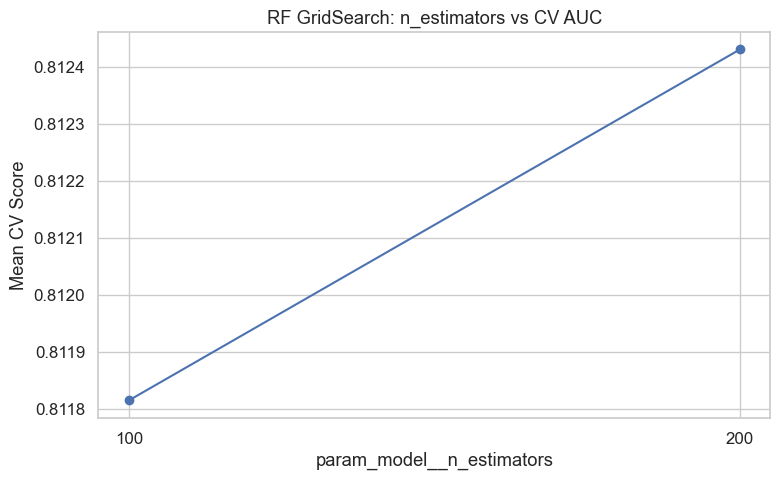

In [32]:
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('fs', SelectKBest(score_func=f_classif, k=10)),
    ('model', RandomForestClassifier(random_state=42))
])

param_grid_rf = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

grid_rf = GridSearchCV(
    rf_pipeline,
    param_grid_rf,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)

grid_rf.fit(X_train, Y_train)
best_rf = grid_rf.best_estimator_

print("Evaluating Random Forest ")
# 1. Predictions
y_train_pred_rf  = best_rf.predict(X_train)
y_train_proba_rf = best_rf.predict_proba(X_train)[:, 1]
y_test_pred_rf   = best_rf.predict(X_test)
y_test_proba_rf  = best_rf.predict_proba(X_test)[:, 1]

# Metrics & Classification Report
print("Classification Report:")
print(classification_report(Y_test, y_test_pred_rf))

# Confusion Matrix
cm = confusion_matrix(Y_test, y_test_pred_rf)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: Random Forest")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
auc_score = roc_auc_score(Y_test, y_test_proba_rf)
fpr, tpr, _ = roc_curve(Y_test, y_test_proba_rf)
plt.figure(figsize=(6, 4))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
plt.plot([0, 1], [0, 1], 'k--')
plt.title(f"ROC Curve: Random Forest")
plt.legend()
plt.show()


--- Evaluating Random Forest ---


Classification Report:
              precision    recall  f1-score   support

           0       0.73      0.73      0.73      8502
           1       0.76      0.75      0.75      9378

    accuracy                           0.74     17880
   macro avg       0.74      0.74      0.74     17880
weighted avg       0.74      0.74      0.74     17880



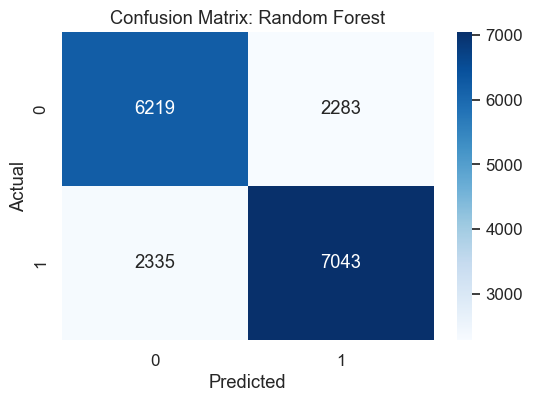

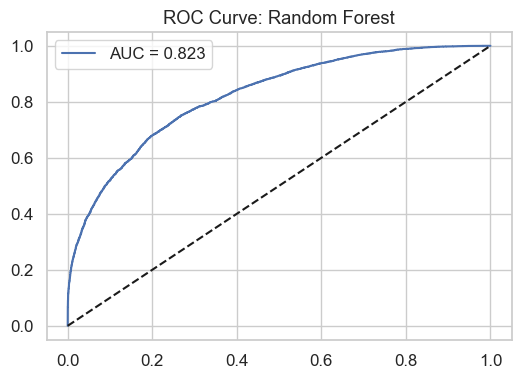

In [33]:
print("--- Evaluating Random Forest ---")
# 1. Predictions
y_pred = best_rf.predict(X_test)
y_prob = None
if hasattr(best_rf, "predict_proba"):
    try: y_prob = best_rf.predict_proba(X_test)[:, 1]
    except: pass
elif hasattr(best_rf, "decision_function"):
    try: 
        y_prob = best_rf.decision_function(X_test)
        y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
    except: pass

# 2. Metrics & Report
print("Classification Report:")
print(classification_report(Y_test, y_pred))

# 3. Validation Matrices
# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix: Random Forest")
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve
if y_prob is not None:
    auc_score = roc_auc_score(Y_test, y_prob)
    fpr, tpr, _ = roc_curve(Y_test, y_prob)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc_score:.3f}")
    plt.plot([0, 1], [0, 1], 'k--')
    plt.title(f"ROC Curve: Random Forest")
    plt.legend()
    plt.show()
else:
    print("ROC Curve not available (no probability/decision function)")



In [34]:
# Subsampling 10k rows for SVM and Ensemble training to improve performance
# as requested (SVM RBF complexity is high on 60k rows)
from sklearn.model_selection import train_test_split

if len(X_train) > 10000:
    print("Subsampling training data for SVM/Ensemble to 10,000 samples...")
    X_train_svm, _, Y_train_svm, _ = train_test_split(X_train, Y_train, train_size=10000, stratify=Y_train, random_state=42)
else:
    X_train_svm, Y_train_svm = X_train, Y_train

print(f"SVM Training Shape: {X_train_svm.shape}")

Subsampling training data for SVM/Ensemble to 10,000 samples...
SVM Training Shape: (10000, 23)


Best SVM Params: {'model__C': 10, 'model__gamma': 0.01}
Best SVM CV AUC: 0.8054614042149586


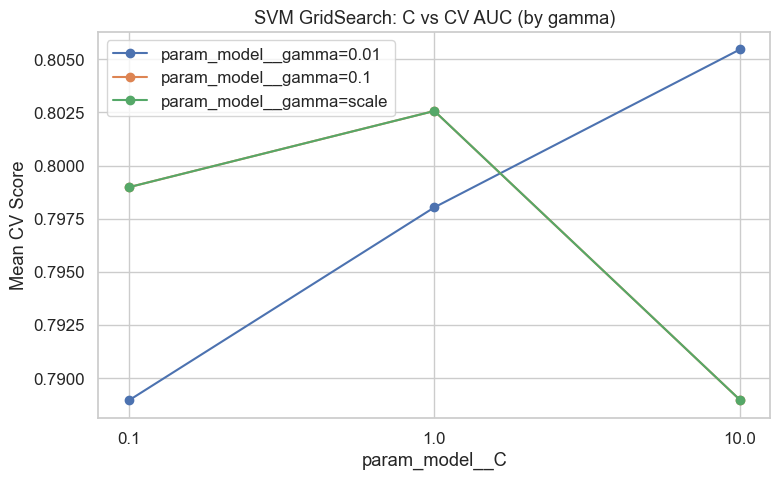

In [35]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('fs', SelectKBest(score_func=f_classif, k=10)),
    ('model', SVC(kernel='rbf', probability=True, random_state=42))
])

param_grid_svm = {
    "model__C": [0.1, 1, 10],
    "model__gamma": ["scale", 0.01, 0.1]
}

grid_svm = GridSearchCV(
    svm_pipeline,
    param_grid_svm,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1,
    refit=True
)

grid_svm.fit(X_train_svm, Y_train_svm)

print("Best SVM Params:", grid_svm.best_params_)
print("Best SVM CV AUC:", grid_svm.best_score_)

plot_gridsearch_results(
    grid_svm,
    x_param="param_model__C",
    hue_param="param_model__gamma",
    title="SVM GridSearch: C vs CV AUC (by gamma)"
)

best_svm = grid_svm.best_estimator_


=== SVM (TUNED): TRAIN ===
Accuracy: 0.7353
AUC: 0.8160429591449069
Confusion Matrix:
 [[3462 1293]
 [1354 3891]]

Classification Report:
               precision    recall  f1-score   support

           0       0.72      0.73      0.72      4755
           1       0.75      0.74      0.75      5245

    accuracy                           0.74     10000
   macro avg       0.73      0.73      0.73     10000
weighted avg       0.74      0.74      0.74     10000


=== SVM (TUNED): TEST ===
Accuracy: 0.7215883668903803
AUC: 0.8039868455926142
Confusion Matrix:
 [[6029 2473]
 [2505 6873]]

Classification Report:
               precision    recall  f1-score   support

           0       0.71      0.71      0.71      8502
           1       0.74      0.73      0.73      9378

    accuracy                           0.72     17880
   macro avg       0.72      0.72      0.72     17880
weighted avg       0.72      0.72      0.72     17880



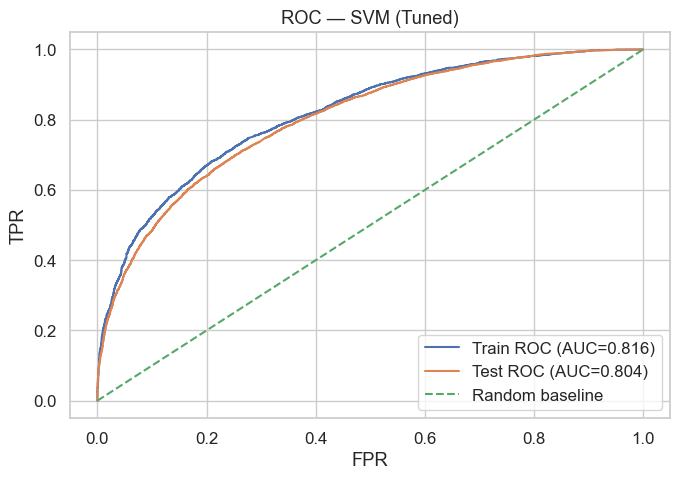

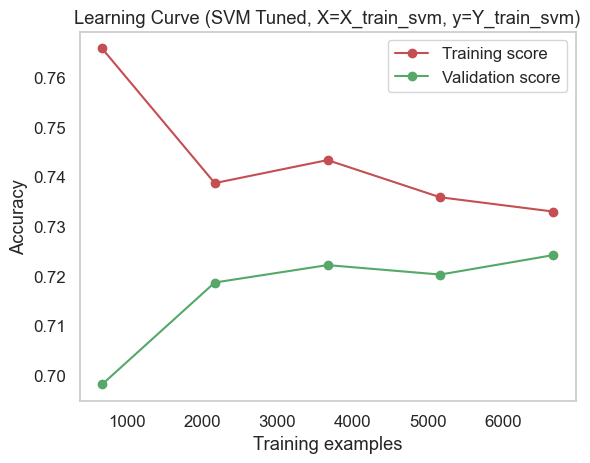

C:\Users\HP\AppData\Local\Temp\ipykernel_10168\1804284064.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_scores, y=top_features, palette='viridis')


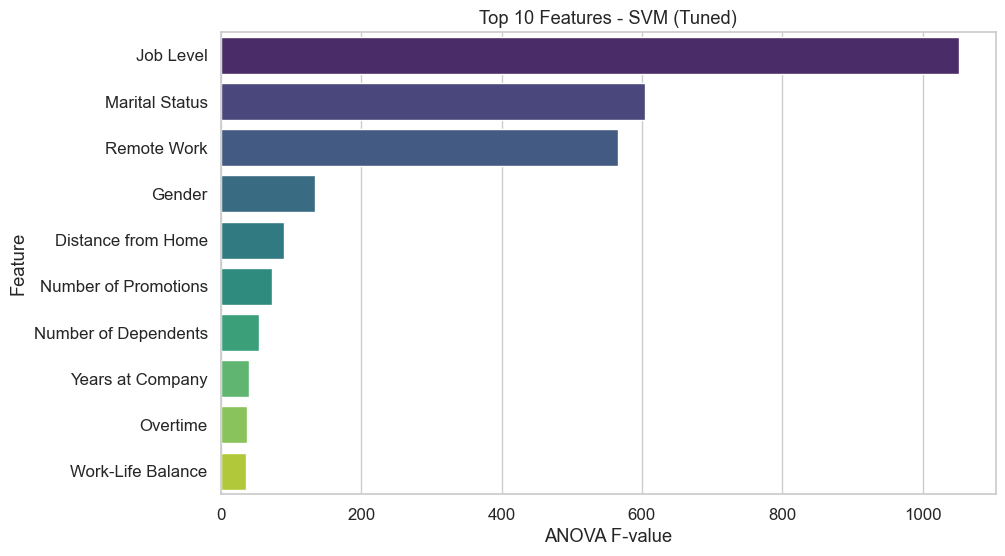

In [36]:
y_train_pred_svm  = best_svm.predict(X_train_svm)
y_train_proba_svm = best_svm.predict_proba(X_train_svm)[:, 1]
y_test_pred_svm   = best_svm.predict(X_test)
y_test_proba_svm  = best_svm.predict_proba(X_test)[:, 1]

print("=== SVM (TUNED): TRAIN ===")
print("Accuracy:", accuracy_score(Y_train_svm, y_train_pred_svm))
print("AUC:", roc_auc_score(Y_train_svm, y_train_proba_svm))
print("Confusion Matrix:\n", confusion_matrix(Y_train_svm, y_train_pred_svm))
print("\nClassification Report:\n", classification_report(Y_train_svm, y_train_pred_svm))

print("\n=== SVM (TUNED): TEST ===")
print("Accuracy:", accuracy_score(Y_test, y_test_pred_svm))
print("AUC:", roc_auc_score(Y_test, y_test_proba_svm))
print("Confusion Matrix:\n", confusion_matrix(Y_test, y_test_pred_svm))
print("\nClassification Report:\n", classification_report(Y_test, y_test_pred_svm))

fpr_tr, tpr_tr, _ = roc_curve(Y_train_svm, y_train_proba_svm)
fpr_te, tpr_te, _ = roc_curve(Y_test,  y_test_proba_svm)

plt.figure(figsize=(7,5))
plt.plot(fpr_tr, tpr_tr, label=f"Train ROC (AUC={roc_auc_score(Y_train_svm, y_train_proba_svm):.3f})")
plt.plot(fpr_te, tpr_te, label=f"Test ROC (AUC={roc_auc_score(Y_test, y_test_proba_svm):.3f})")
plt.plot([0, 1], [0, 1], "--", label="Random baseline")
plt.title("ROC — SVM (Tuned)")
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.grid(True); plt.legend(); plt.tight_layout()
plt.show()

plot_learning_curve_model(best_svm, "Learning Curve (SVM Tuned, X=X_train_svm, y=Y_train_svm)", X=X_train_svm, y=Y_train_svm)
visualize_pipeline_features(best_svm, X_train.columns, "SVM (Tuned)")


# Task 2: Model Building - Ensemble Models
We will now combine the strengths of these models using Ensemble techniques:
1.  **Voting Classifier** (Soft Voting)
2.  **Stacking Classifier**
3.  **Bagging Classifier**


--- Evaluating Soft Voting Ensemble ---
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.71      0.71      8502
           1       0.74      0.75      0.74      9378

    accuracy                           0.73     17880
   macro avg       0.73      0.73      0.73     17880
weighted avg       0.73      0.73      0.73     17880



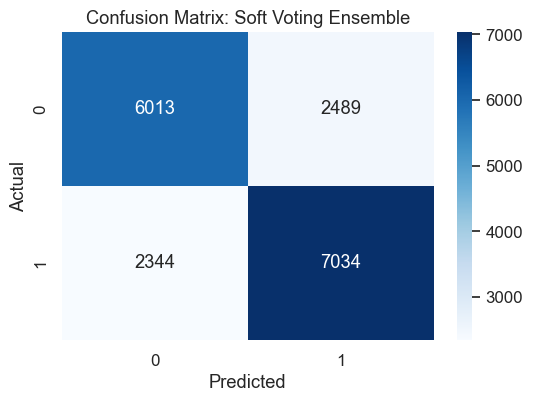

In [37]:
# --- Soft Voting Ensemble ---
from sklearn.ensemble import VotingClassifier
voting_clf_soft = VotingClassifier(
    estimators=[('lr', best_lr), ('rf', best_rf), ('svm', best_svm)],
    voting='soft'
)
voting_clf_soft.fit(X_train, Y_train)

print('--- Evaluating Soft Voting Ensemble ---')
y_pred = voting_clf_soft.predict(X_test)

print('Classification Report:')
print(classification_report(Y_test, y_pred))

cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Soft Voting Ensemble')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

--- Evaluating Hard Voting Ensemble ---
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.72      0.72      8502
           1       0.74      0.75      0.74      9378

    accuracy                           0.73     17880
   macro avg       0.73      0.73      0.73     17880
weighted avg       0.73      0.73      0.73     17880



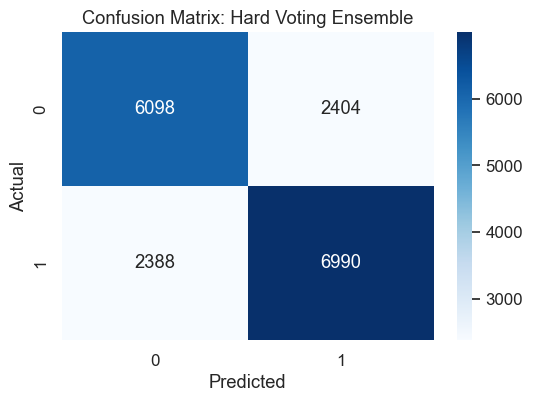

In [38]:
# --- Hard Voting Ensemble ---
voting_clf_hard = VotingClassifier(
    estimators=[('lr', best_lr), ('rf', best_rf), ('svm', best_svm)],
    voting='hard'
)
voting_clf_hard.fit(X_train, Y_train)

print('--- Evaluating Hard Voting Ensemble ---')
y_pred = voting_clf_hard.predict(X_test)

print('Classification Report:')
print(classification_report(Y_test, y_pred))

cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Hard Voting Ensemble')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# ROC Curve skipped for Hard Voting (no probability output)


--- Evaluating Bagging Classifier ---
Classification Report:
              precision    recall  f1-score   support

           0       0.70      0.69      0.69      8502
           1       0.72      0.73      0.72      9378

    accuracy                           0.71     17880
   macro avg       0.71      0.71      0.71     17880
weighted avg       0.71      0.71      0.71     17880



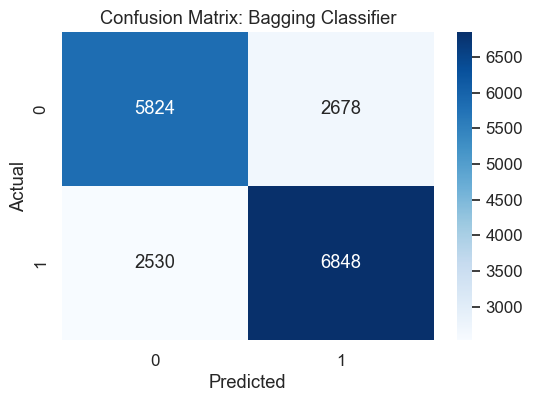

In [39]:
# --- Bagging Classifier ---
from sklearn.ensemble import BaggingClassifier
bagging_clf = BaggingClassifier(
    estimator=best_lr, 
    n_estimators=20, 
    random_state=42
)
bagging_clf.fit(X_train, Y_train)

print('--- Evaluating Bagging Classifier ---')
y_pred = bagging_clf.predict(X_test)

print('Classification Report:')
print(classification_report(Y_test, y_pred))

cm = confusion_matrix(Y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix: Bagging Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

# Task 2: Model Comparison
Comparison of all implemented models based on Accuracy.


=== MODEL COMPARISON TABLE ===
                 Model  Accuracy  F1 (macro)  F1 (weighted)       AUC
1        Random Forest  0.741723    0.741173       0.741757  0.822857
4          Hard Voting  0.731991    0.731322       0.731979  0.500000
3          Soft Voting  0.729698    0.728814       0.729572  0.813674
2                  SVM  0.721588    0.720967       0.721612  0.803987
0  Logistic Regression  0.709060    0.708173       0.708961  0.787457
5              Bagging  0.708725    0.707766       0.708586  0.787540


C:\Users\HP\AppData\Local\Temp\ipykernel_10168\104427656.py:44: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="Accuracy", y="Model", data=comparison_df, palette="viridis")


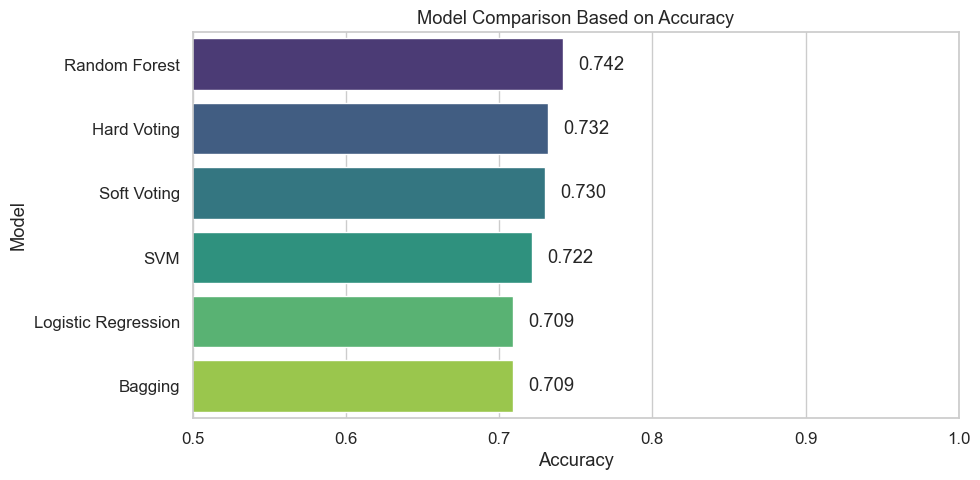

In [40]:
results = []

# Helper to collect results safely
def try_collect(name, model, y_true, y_pred, X_test):
    y_prob = None
    if hasattr(model, 'predict_proba'):
        try: y_prob = model.predict_proba(X_test)[:, 1]
        except: pass
    elif hasattr(model, 'decision_function'):
        try: 
            y_prob = model.decision_function(X_test)
            y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min())
        except: pass
    
    res = {
        "Model": name,
        "Accuracy": accuracy_score(y_true, y_pred),
        "F1 (macro)": f1_score(y_true, y_pred, average="macro"),
        "F1 (weighted)": f1_score(y_true, y_pred, average="weighted")
    }
    if y_prob is not None:
        res["AUC"] = roc_auc_score(y_true, y_prob)
    else:
        res["AUC"] = 0.5 # Default/Unknown
    return res

# Collect from all models
# We need to re-generate predictions for fairness/consistency if variables aren't handy,
# but assuming they were run above, we can just use the models.

results.append(try_collect("Logistic Regression", best_lr, Y_test, best_lr.predict(X_test), X_test))
results.append(try_collect("Random Forest", best_rf, Y_test, best_rf.predict(X_test), X_test))
results.append(try_collect("SVM", best_svm, Y_test, best_svm.predict(X_test), X_test))
results.append(try_collect("Soft Voting", voting_clf_soft, Y_test, voting_clf_soft.predict(X_test), X_test))
results.append(try_collect("Hard Voting", voting_clf_hard, Y_test, voting_clf_hard.predict(X_test), X_test))
results.append(try_collect("Bagging", bagging_clf, Y_test, bagging_clf.predict(X_test), X_test))

comparison_df = pd.DataFrame(results).sort_values(by="Accuracy", ascending=False)

print("=== MODEL COMPARISON TABLE ===")
print(comparison_df)

plt.figure(figsize=(10, 5))
sns.barplot(x="Accuracy", y="Model", data=comparison_df, palette="viridis")
plt.title("Model Comparison Based on Accuracy")
plt.xlim(0.5, 1.0)
for i, v in enumerate(comparison_df["Accuracy"]):
    plt.text(v + 0.01, i, f"{v:.3f}", va="center")
plt.tight_layout()
plt.show()
